In [130]:
# Import important library
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn import model_selection
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [131]:
german_credit = pd.read_csv("german_credit.csv")

In [132]:
german_credit.shape

(1000, 21)

In [133]:
german_credit.columns

Index(['default', 'account_check_status', 'duration_in_month',
       'credit_history', 'purpose', 'credit_amount', 'savings',
       'present_emp_since', 'installment_as_income_perc',
       'personal_status_sex', 'other_debtors', 'present_res_since', 'property',
       'age', 'other_installment_plans', 'housing', 'credits_this_bank', 'job',
       'people_under_maintenance', 'telephone', 'foreign_worker'],
      dtype='object')

In [134]:
german_credit.head().T

,0,1,2,3,4
default,0,1,0,0,1
account_check_status,< 0 DM,0 <= ... < 200 DM,no checking account,< 0 DM,< 0 DM
duration_in_month,6,48,12,42,24
credit_history,critical account/ other credits existing (not ...,existing credits paid back duly till now,critical account/ other credits existing (not ...,existing credits paid back duly till now,delay in paying off in the past
purpose,domestic appliances,domestic appliances,(vacation - does not exist?),radio/television,car (new)
credit_amount,1169,5951,2096,7882,4870
savings,unknown/ no savings account,... < 100 DM,... < 100 DM,... < 100 DM,... < 100 DM
present_emp_since,.. >= 7 years,1 <= ... < 4 years,4 <= ... < 7 years,4 <= ... < 7 years,1 <= ... < 4 years
installment_as_income_perc,4,2,2,2,3
personal_status_sex,male : single,female : divorced/separated/married,male : single,male : single,male : single


In [135]:
german_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [136]:
german_credit.apply(lambda x : sum(x.isnull()))

default                       0
account_check_status          0
duration_in_month             0
credit_history                0
purpose                       0
credit_amount                 0
savings                       0
present_emp_since             0
installment_as_income_perc    0
personal_status_sex           0
other_debtors                 0
present_res_since             0
property                      0
age                           0
other_installment_plans       0
housing                       0
credits_this_bank             0
job                           0
people_under_maintenance      0
telephone                     0
foreign_worker                0
dtype: int64

In [137]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [138]:
german_df = german_credit.sample(n=500)
german_df.shape

(500, 21)

In [139]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [140]:
y=german_df[['default']]
X=german_df.drop(['default'],axis=1)
X = pd.get_dummies(X,drop_first=True)

In [141]:
X.shape

(500, 48)

In [142]:
X.columns

Index(['duration_in_month', 'credit_amount', 'installment_as_income_perc',
       'present_res_since', 'age', 'credits_this_bank',
       'people_under_maintenance', 'account_check_status_< 0 DM',
       'account_check_status_>= 200 DM / salary assignments for at least 1 year',
       'account_check_status_no checking account',
       'credit_history_critical account/ other credits existing (not at this bank)',
       'credit_history_delay in paying off in the past',
       'credit_history_existing credits paid back duly till now',
       'credit_history_no credits taken/ all credits paid back duly',
       'purpose_business', 'purpose_car (new)', 'purpose_car (used)',
       'purpose_domestic appliances', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_radio/television',
       'purpose_repairs', 'purpose_retraining', 'savings_... < 100 DM',
       'savings_100 <= ... < 500 DM', 'savings_500 <= ... < 1000 DM ',
       'savings_unknown/ no savings account',
       '

In [143]:
X.head()

,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,account_check_status_no checking account,...,property_unknown / no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",foreign_worker_yes
113,36,7855,4,2,25,2,1,0,0,1,...,0,0,1,1,0,1,0,0,1,1
423,21,1591,4,3,34,2,1,0,0,1,...,0,1,0,1,0,0,0,0,0,1
76,42,3965,4,3,34,1,1,1,0,0,...,0,1,0,1,0,1,0,0,0,1
525,26,7966,2,3,30,2,1,0,0,0,...,0,1,0,1,0,1,0,0,0,1
338,24,4169,4,4,28,1,1,1,0,0,...,0,1,0,1,0,1,0,0,0,1


### Check for highly correlated variables but don't required any treatment for this use case

In [144]:
X.corr() 


,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,account_check_status_no checking account,...,property_unknown / no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",foreign_worker_yes
duration_in_month,1.000000,0.687849,0.040911,0.026317,-0.075932,-0.054682,-0.040645,-0.007319,-0.058709,-0.020387,...,0.217292,-0.082812,0.099746,-0.084275,-0.070986,0.006500,-0.043443,-0.174783,0.156884,0.117724
credit_amount,0.687849,1.000000,-0.258865,-0.004971,-0.021190,0.005911,0.024032,-0.033273,-0.091602,-0.013749,...,0.189705,-0.047708,0.022410,-0.131825,0.006769,-0.087064,-0.053582,-0.162090,0.257431,0.023116
installment_as_income_perc,0.040911,-0.258865,1.000000,0.089648,0.047126,0.034076,-0.085667,0.041954,-0.016412,0.067134,...,0.044993,-0.016653,0.096776,0.091201,-0.107592,0.020197,-0.055272,-0.061964,0.007851,0.116217
present_res_since,0.026317,-0.004971,0.089648,1.000000,0.276277,0.068345,0.054819,0.100871,-0.077389,-0.026892,...,0.152884,-0.023741,0.003288,-0.310545,0.198459,0.017459,-0.013852,0.036673,0.087558,0.049561
age,-0.075932,-0.021190,0.047126,0.276277,1.000000,0.217088,0.142908,-0.019325,0.004494,0.088398,...,0.194666,-0.102435,0.045920,-0.004548,-0.233762,-0.132209,0.092006,0.063791,0.139406,0.052556
credits_this_bank,-0.054682,0.005911,0.034076,0.068345,0.217088,1.000000,0.113544,-0.044345,-0.050361,0.101106,...,-0.004802,-0.097980,0.031899,0.018064,-0.037070,0.001027,0.069857,-0.022780,0.036581,0.035522
people_under_maintenance,-0.040645,0.024032,-0.085667,0.054819,0.142908,0.113544,1.000000,0.083644,-0.040761,-0.025799,...,0.058971,-0.092914,-0.003873,-0.004403,-0.102501,-0.095793,-0.005240,0.152057,-0.042980,-0.072828
account_check_status_< 0 DM,-0.007319,-0.033273,0.041954,0.100871,-0.019325,-0.044345,0.083644,1.000000,-0.158738,-0.483372,...,-0.001875,0.021749,0.050439,-0.112228,0.087846,0.030880,-0.023432,0.049811,-0.093154,-0.056979
account_check_status_>= 200 DM / salary assignments for at least 1 year,-0.058709,-0.091602,-0.016412,-0.077389,0.004494,-0.050361,-0.040761,-0.158738,1.000000,-0.201275,...,-0.059328,-0.030339,0.011962,0.056686,-0.036471,-0.042347,0.107179,0.004987,-0.040629,-0.089053
account_check_status_no checking account,-0.020387,-0.013749,0.067134,-0.026892,0.088398,0.101106,-0.025799,-0.483372,-0.201275,1.000000,...,-0.008635,0.059686,-0.022971,0.089175,-0.074011,0.031372,-0.082922,-0.035369,0.084108,0.078667


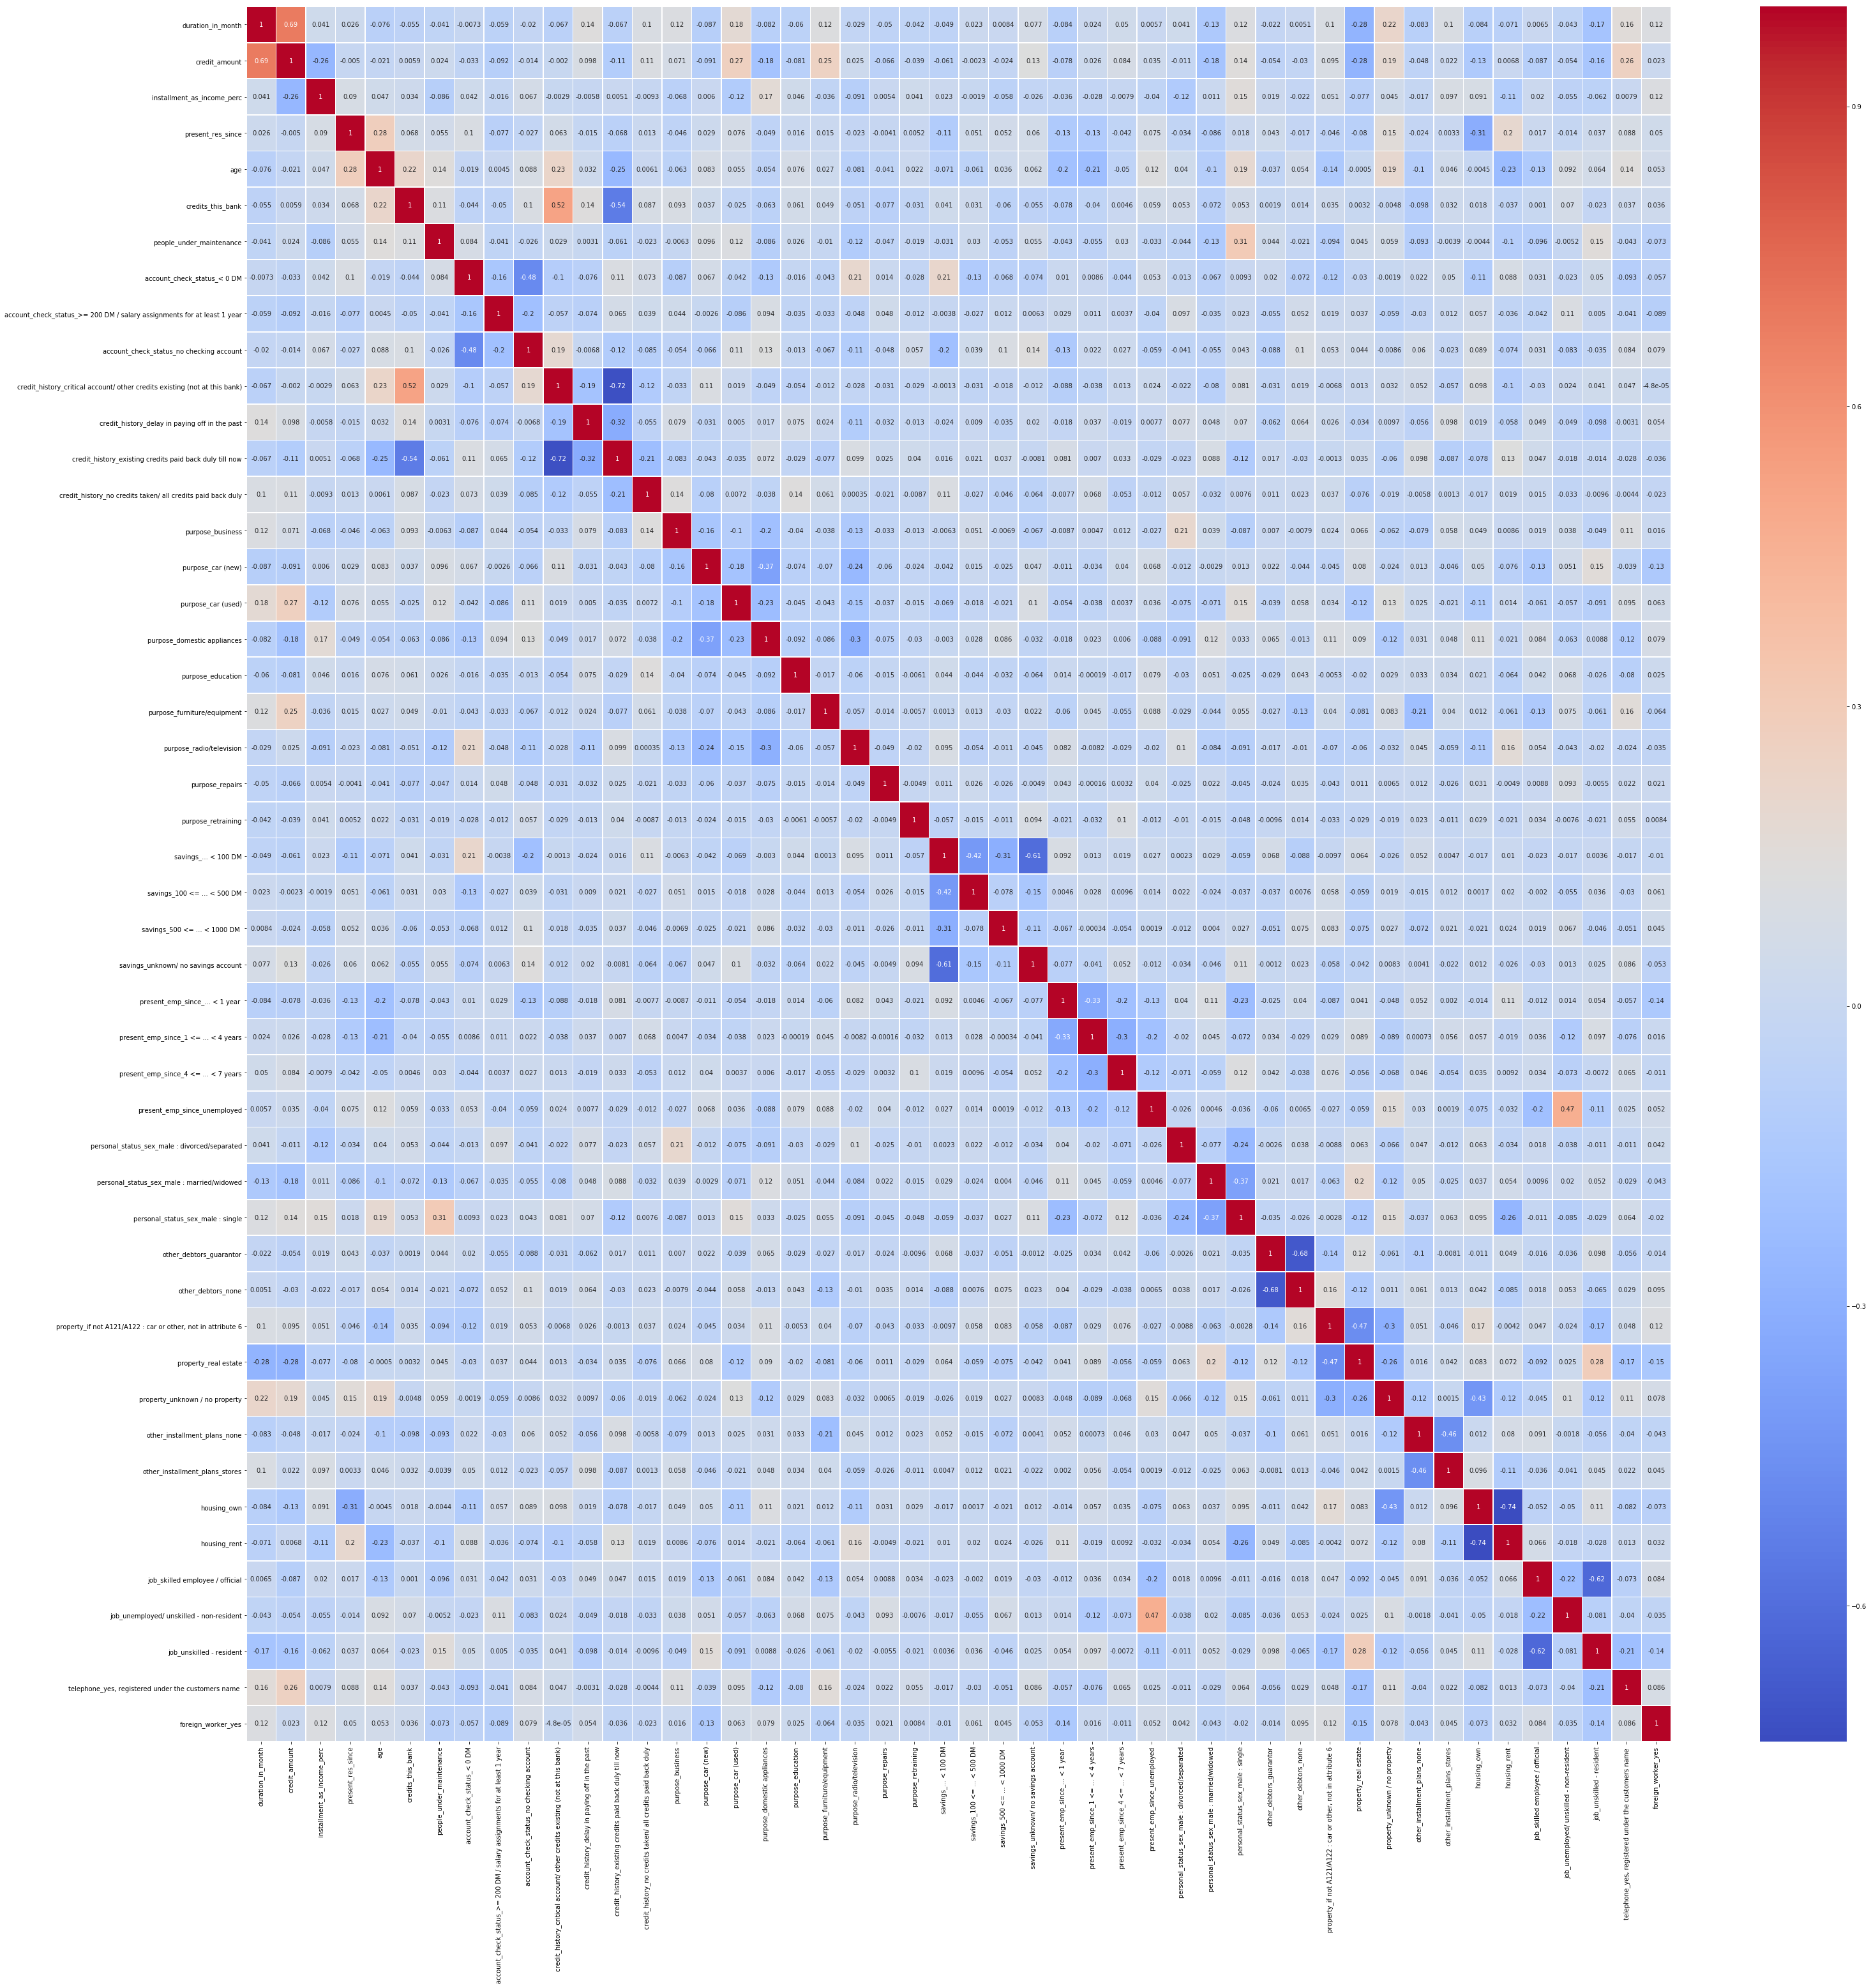

In [145]:
fig, ax = plt.subplots(figsize=(50,50))
sns.heatmap(X.corr(), annot=True, linewidths=0.8, ax=ax,cmap='coolwarm')

In [146]:
# credit amount and duration in month are correlated with a score of 0.66
# Other debtor guarantor has correlation with other debtor none with a score of 0.68
# Housing own and housing rent are correlated with a score of 0.78
# Negative correlation is there between job unemployed/unskilled-non-resident and job-unskilled-resident with a score of -0.67

### Drop the original variables which are converted to dummy

In [147]:
# allready dropped

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [148]:
test_size = 0.3 # taking 70:30 training and test set
seed = 4  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [149]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500,n_jobs=2,criterion = 'entropy',random_state = 9999)
rf.fit(X_train, y_train)
y_predict=rf.predict(X_test)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [150]:
metrics.confusion_matrix(y_test,y_predict)

array([[93, 10],
       [32, 15]], dtype=int64)

In [151]:
metrics.accuracy_score(y_test,y_predict)

0.72

### Q6 Show the list of the features importance( 1 Marks)

In [152]:
cols = X.columns
df = pd.DataFrame(rf.feature_importances_,index=cols,columns=['score'])
#rf.feature_importances_
df.sort_values('score',ascending=False)

,score
credit_amount,0.110481
age,0.093665
duration_in_month,0.084978
account_check_status_no checking account,0.053786
installment_as_income_perc,0.048509
present_res_since,0.036196
account_check_status_< 0 DM,0.032789
present_emp_since_4 <= ... < 7 years,0.026311
credit_history_critical account/ other credits existing (not at this bank),0.025039
other_installment_plans_none,0.021469


### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [153]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [154]:
# Use below values
num_folds = 10
seed = 77

In [155]:
#Validate the Random Forest model build above using k fold

In [156]:
kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
cv = model_selection.cross_val_score(rf, X, y, cv=kfold)



In [157]:
#Calculate Mean score

In [158]:
cv.mean()

0.748

In [159]:
# Calculate score standard deviation using std()

In [160]:
cv.std()

0.06584831053261729

# Q8 Print the confusion matrix( 1 Marks)

In [161]:
metrics.confusion_matrix(y_test,y_predict)

array([[93, 10],
       [32, 15]], dtype=int64)

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [162]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.72
Test Recall    = 0.3191489361702128
Test Precision = 0.6
Test F1score   = 0.4166666666666667


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [0]:
#Hint: Use roc_curve

In [163]:
from sklearn.metrics import roc_curve, auc
y_predictProb = rf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])
roc_auc = auc(fpr, tpr)
roc_auc

0.7552158644908077

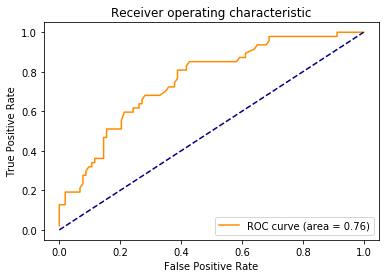

In [164]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [0]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [0]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    rfm.fit(X_, y_)
    y_pred = rfm.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [0]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.6893333333333334
Standard deviation:  0.014966629547095768
